<a href="https://colab.research.google.com/github/vuleanhduc2706/TH_DeepLearning/blob/main/Tuan02_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Đang đọc, làm sạch và xử lý dữ liệu...
2. Đang chuẩn hóa dữ liệu...
3. Đang huấn luyện mô hình Deep Learning...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


-> Huấn luyện tự động dừng ở Epoch thứ 38 do Early Stopping!
4. Đang vẽ biểu đồ đánh giá...


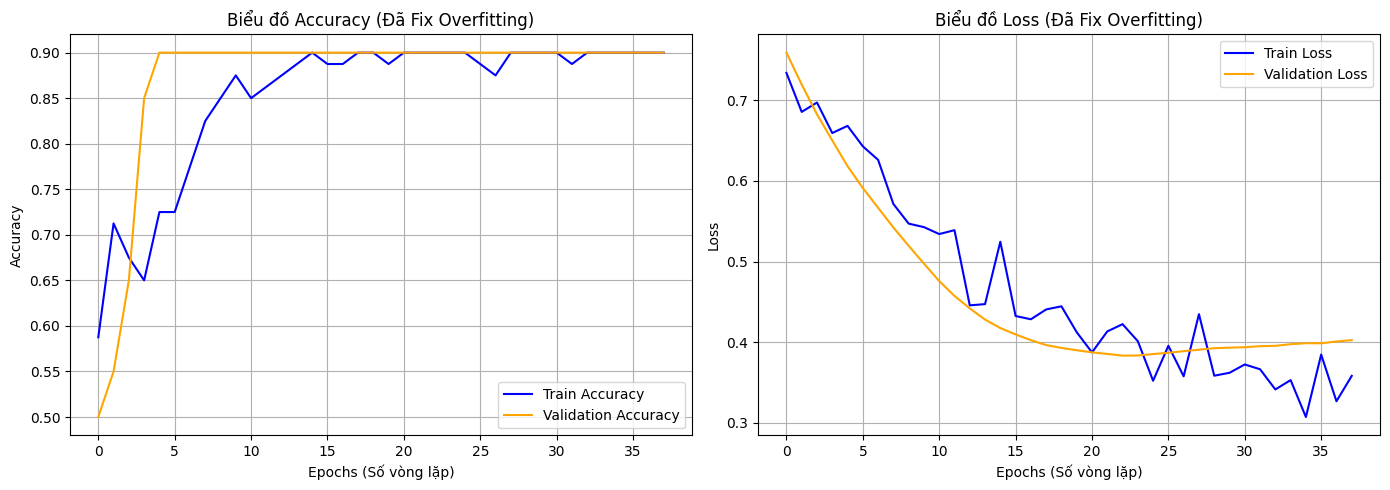

In [6]:
# ==========================================
# IMPORT CÁC THƯ VIỆN CẦN THIẾT
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ==========================================
# BƯỚC 1: LÀM SẠCH VÀ RÚT GỌN DỮ LIỆU (CHỐNG OVERFIT TỪ GỐC)
# ==========================================
print("1. Đang đọc, làm sạch và xử lý dữ liệu...")
# Đọc file dữ liệu (Nhớ đảm bảo file đã được tải lên Colab)
df = pd.read_csv('dulieuxettuyendaihoc.csv')

# Xóa cột STT và điền khuyết cột Dân Tộc
df = df.drop(columns=['STT'])
df['DT'] = df['DT'].fillna(0)

# Tạo nhãn (Label): Tổng 3 môn đại học >= 15 là Đậu (1), ngược lại là Rớt (0)
df['KetQua'] = ((df['DH1'] + df['DH2'] + df['DH3']) >= 15).astype(int)

# --- Feature Engineering: Gộp điểm 6 học kỳ thành Điểm Trung Bình ---
subjects = ['T', 'L', 'H', 'S', 'V', 'X', 'D', 'N']
for sub in subjects:
    # Lấy tên 6 cột của môn đó (VD: T1, T2, T3, T4, T5, T6)
    cols = [f'{sub}{i}' for i in range(1, 7)]
    # Tính điểm trung bình và tạo cột mới
    df[f'{sub}_avg'] = df[cols].mean(axis=1).round(2)
    # Xóa các cột điểm lẻ đi cho mô hình bớt rối
    df = df.drop(columns=cols)

# Tách đặc trưng (X) và nhãn (y)
X = df.drop(columns=['DH1', 'DH2', 'DH3', 'KetQua'])
y = df['KetQua']

# Chia tập Train / Test. Dùng stratify=y để cân bằng tỷ lệ Đậu/Rớt
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# BƯỚC 2: CHUẨN HÓA DỮ LIỆU (CHỈ FIT TRÊN TRAIN)
# ==========================================
print("2. Đang chuẩn hóa dữ liệu...")
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Chuẩn hóa dữ liệu Số
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

# Chuẩn hóa dữ liệu Chuỗi
X_train_cat = X_train[cat_cols].copy()
X_test_cat = X_test[cat_cols].copy()

for col in cat_cols:
    le = LabelEncoder()
    X_train_cat[col] = le.fit_transform(X_train_cat[col].astype(str))
    # Xử lý nhãn lạ trong tập Test
    test_classes = X_test_cat[col].astype(str).unique()
    for c in test_classes:
        if c not in le.classes_:
            le.classes_ = np.append(le.classes_, c)
    X_test_cat[col] = le.transform(X_test_cat[col].astype(str))

# Ghép dữ liệu và chuyển về float32 cho Keras
X_train_scaled = np.hstack((X_train_num, X_train_cat.values)).astype('float32')
X_test_scaled = np.hstack((X_test_num, X_test_cat.values)).astype('float32')
y_train = y_train.values.astype('float32')
y_test = y_test.values.astype('float32')

# ==========================================
# BƯỚC 3: XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH (CÓ PHANH HÃM)
# ==========================================
print("3. Đang huấn luyện mô hình Deep Learning...")
# Khởi tạo mạng Neural với Dropout để chống học vẹt
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3), # Tắt ngẫu nhiên 30% nơ-ron
    Dense(8, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Cài đặt Early Stopping: Tự dừng nếu sau 15 vòng mà Validation Loss không giảm
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=15, restore_best_weights=True)

# Bắt đầu huấn luyện
history = model.fit(X_train_scaled, y_train,
                    validation_data=(X_test_scaled, y_test),
                    epochs=100, batch_size=8,
                    callbacks=[early_stop],
                    verbose=0)

print(f"-> Huấn luyện tự động dừng ở Epoch thứ {len(history.history['loss'])} do Early Stopping!")

# ==========================================
# BƯỚC 4: VẼ BIỂU ĐỒ LOSS VÀ ACCURACY
# ==========================================
print("4. Đang vẽ biểu đồ đánh giá...")
plt.figure(figsize=(14, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Biểu đồ Accuracy (Đã Fix Overfitting)')
plt.xlabel('Epochs (Số vòng lặp)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Biểu đồ Loss (Đã Fix Overfitting)')
plt.xlabel('Epochs (Số vòng lặp)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()